In [5]:
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import glob

LATENT_DIM = 100
BATCH_SIZE = 16
EPOCHS = 30
DATASET_PATH = "../data/captcha"

In [6]:
class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super(Generator, self).__init__()
        self.latent_dim = latent_dim
        self.main = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, 2048),
            nn.ReLU(True),
            nn.Linear(2048, 50 * 200),  # 50x200 for images
            nn.Tanh(),
        )

    def forward(self, z):
        return self.main(z).view(-1, 50, 200)


class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(50 * 200, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.view(-1, 50 * 200)
        return self.main(x)


class CaptchaDataset(Dataset):
    def __init__(self, data_dir):
        self.image_paths = glob.glob(str(Path(data_dir) / "*.png"))
        print(f"Found {len(self.image_paths)} CAPTCHA images")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index]).convert("L")
        image = image.resize((200, 50))
        image = np.array(image).astype(np.float32) / 255.0
        image = (image - 0.5) / 0.5  # Normalize to [-1, 1]
        return torch.tensor(image)

In [7]:
def visualize_generation(generator, num_samples=8, device="cpu"):
    """Generate and display CAPTCHA images"""
    generator.eval()
    with torch.no_grad():
        noise = torch.randn(num_samples, generator.latent_dim).to(device)
        generated_imgs = generator(noise).cpu().numpy()
        generated_imgs = (generated_imgs + 1) / 2  # Denormalize to [0, 1]

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i, ax in enumerate(axes.flat):
        if i < num_samples:
            ax.imshow(generated_imgs[i], cmap="gray")
        ax.axis("off")
    plt.suptitle("Generated CAPTCHA Images")
    plt.show()

In [8]:
np.random.seed(42)
torch.manual_seed(42)

# Load dataset
dataset = CaptchaDataset(DATASET_PATH)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# Initialize models
latent_dim = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = Generator(latent_dim=LATENT_DIM).to(device)
discriminator = Discriminator().to(device)

# Loss function
criterion = nn.BCELoss()

print(f"Using device: {device}")
print(f"Generator parameters: {sum(p.numel() for p in generator.parameters()):,}")
print(
    f"Discriminator parameters: {sum(p.numel() for p in discriminator.parameters()):,}"
)

# do we have saved models
gen_path = Path("captcha_generator.pth")
disc_path = Path("captcha_discriminator.pth")

if gen_path.exists() and disc_path.exists():
    generator.load_state_dict(torch.load(gen_path, map_location=device))
    discriminator.load_state_dict(torch.load(disc_path, map_location=device))
    print("Loaded trained models")
else:
    print("Train GAN...")

if not (gen_path.exists() and disc_path.exists()):
    optimizer_G = torch.optim.Adam(
        generator.parameters(), lr=0.0002, betas=(0.5, 0.999)
    )
    optimizer_D = torch.optim.Adam(
        discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999)
    )

    G_losses = []
    D_losses = []

    for epoch in range(EPOCHS):
        epoch_g_loss = 0
        epoch_d_loss = 0
        num_batches = 0

        for batch_idx, real_data in enumerate(dataloader):
            batch_size = real_data.size(0)
            real_data = real_data.to(device)

            # Create labels
            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)

            # Train Discriminator
            optimizer_D.zero_grad()

            # Real data
            real_output = discriminator(real_data)
            d_loss_real = criterion(real_output, real_labels)

            # Fake data
            noise = torch.randn(batch_size, LATENT_DIM).to(device)
            fake_data = generator(noise)
            fake_output = discriminator(fake_data.detach())
            d_loss_fake = criterion(fake_output, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            optimizer_D.step()

            # Train Generator
            optimizer_G.zero_grad()
            fake_output = discriminator(fake_data)
            g_loss = criterion(fake_output, real_labels)
            g_loss.backward()
            optimizer_G.step()

            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()
            num_batches += 1

        # Store average losses
        G_losses.append(epoch_g_loss / num_batches)
        D_losses.append(epoch_d_loss / num_batches)

        print(
            f"Epoch {epoch+1}/{EPOCHS}, D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}"
        )

    torch.save(generator.state_dict(), gen_path)
    torch.save(discriminator.state_dict(), disc_path)
    print("the models were saved")

Found 134 CAPTCHA images
Using device: cpu
Generator parameters: 23,166,224
Discriminator parameters: 10,897,409
Train GAN...
Epoch 1/30, D Loss: 1.3554, G Loss: 0.6789
Epoch 2/30, D Loss: 1.3413, G Loss: 0.5472
Epoch 3/30, D Loss: 1.1707, G Loss: 0.8303
Epoch 4/30, D Loss: 1.0867, G Loss: 0.9713
Epoch 5/30, D Loss: 1.6325, G Loss: 0.7394
Epoch 6/30, D Loss: 1.4386, G Loss: 0.8605
Epoch 7/30, D Loss: 1.2885, G Loss: 0.6402
Epoch 8/30, D Loss: 1.5186, G Loss: 0.5210
Epoch 9/30, D Loss: 1.4066, G Loss: 0.7031
Epoch 10/30, D Loss: 1.2788, G Loss: 0.9442
Epoch 11/30, D Loss: 1.2859, G Loss: 0.9203
Epoch 12/30, D Loss: 1.1867, G Loss: 0.6956
Epoch 13/30, D Loss: 1.2693, G Loss: 0.8017
Epoch 14/30, D Loss: 1.3424, G Loss: 0.5055
Epoch 15/30, D Loss: 1.3619, G Loss: 0.6838
Epoch 16/30, D Loss: 1.5530, G Loss: 0.6420
Epoch 17/30, D Loss: 1.1708, G Loss: 0.6424
Epoch 18/30, D Loss: 1.4318, G Loss: 1.0945
Epoch 19/30, D Loss: 1.3905, G Loss: 1.0836
Epoch 20/30, D Loss: 1.3524, G Loss: 0.6919
Epo

# Test

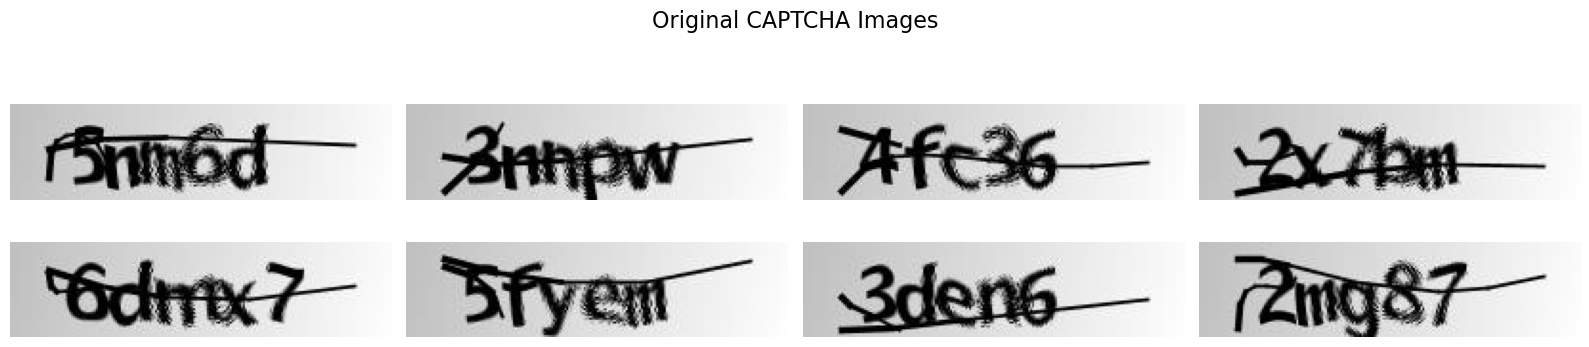

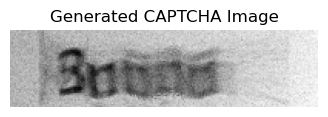

In [9]:
# show original images
real_batch = next(iter(dataloader))


plt.figure(figsize=(16, 4))
plt.suptitle("Original CAPTCHA Images", fontsize=16)


for i in range(min(8, real_batch.size(0))):
    plt.subplot(2, 4, i + 1)

    img = real_batch[i].numpy()
    img = (img + 1) / 2  # Denormalize
    plt.imshow(img, cmap="gray")

    plt.axis("off")


plt.tight_layout()

plt.show()

# generate an image
generator.eval()
with torch.no_grad():
    noise = torch.randn(1, generator.latent_dim).to(device)
    generated_img = generator(noise).cpu().numpy()
    generated_img = (generated_img + 1) / 2  # Denormalize to [0, 1]
    img = generated_img[0]

plt.figure(figsize=(4, 1))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title("Generated CAPTCHA Image")
plt.show()